# 09 — Does a price-momentum gate improve directionality?

**Objective.** *"see if including this momentum tracker from price
direction improves our directionality"* — tested on the theme anchor
ETFs.

The gate under test is the five-condition screen, applied in two
windows. All five must hold for a window to pass:

| # | EMERGING MOMENTUM (EM) — medium | EARLY STAGE (ES) — short |
|---|---|---|
| 1 | `ret_1m_pctile` ≥ 85 (own history, 252 obs) | `ret_2w_pctile` ≥ 85 |
| 2 | `accel_z` ≥ 1.0 (own history, 252 obs) | `accel_es_z` ≥ 1.0 |
| 3 | `above_50dma` = 1 | `above_20dma` = 1 |
| 4 | `pct_below_52w_high` ≤ 10 | `pct_below_26w_high` ≤ 10 |
| 5 | `return_1m_pct` > 0 | `return_2week_pct` > 0 |

A name clearing both is `BOTH`.

**This notebook changes nothing.** It reads the shipped stores, builds
its own gate columns and its own forward returns, and reports. No file
in `analytics/`, `src/` or `config/` is touched — adoption, if any, is
a separate decision taken after reading this.

**What "directionality" means here.** A signal is *correct* when price
moves the way the signal implies: INCREASE EXPOSURE → price rises,
CUT EXPOSURE → price falls, measured over 5, 10 and 20 trading days
from the signal date. The question is whether requiring the momentum
gate ON THE SIGNAL DATE raises that hit rate.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
from scipy import stats as sps

ROOT = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.themes import _load_theme_etfs                      # noqa: E402

THEME_ETFS, _ = _load_theme_etfs()
PX = pd.read_parquet(os.path.join(ROOT, "data", "prices", "prices.parquet"))
DESK = pd.read_parquet(os.path.join(ROOT, "data", "processed",
                                    "euphoria_desk.parquet"))
DESK = DESK[DESK["kind"] == "theme"].copy()
DESK["date"] = pd.to_datetime(DESK["date"])
print(f"themes {DESK['name'].nunique()} | "
      f"{DESK['date'].min():%Y-%m-%d} -> {DESK['date'].max():%Y-%m-%d}")

themes 33 | 2017-08-27 -> 2026-08-21


## 1. The gates

Every window is TRAILING and every percentile is against the name's own
trailing 252 observations, as specified. No forward data enters any
column below — that is the property that makes the test honest rather
than a restatement of the answer.

In [2]:
def add_gates(px_one: pd.DataFrame) -> pd.DataFrame:
    """Five-gate screen for one symbol's close series."""
    d = px_one.sort_values("date").copy()
    c = d["px_last"]

    # EM — medium window
    d["return_1m_pct"] = c.pct_change(21) * 100
    d["ret_1m_pctile"] = (d["return_1m_pct"].rolling(252, min_periods=252)
                          .rank(pct=True) * 100)
    _acc = d["return_1m_pct"] - d["return_1m_pct"].shift(21)
    d["accel_z"] = ((_acc - _acc.rolling(252, min_periods=252).mean())
                    / _acc.rolling(252, min_periods=252).std())
    d["above_50dma"] = (c > c.rolling(50, min_periods=50).mean()).astype(float)
    _52 = c.rolling(252, min_periods=252).max()
    d["pct_below_52w_high"] = (_52 - c) / _52 * 100
    d["EM"] = ((d["ret_1m_pctile"] >= 85) & (d["accel_z"] >= 1.0)
               & (d["above_50dma"] == 1) & (d["pct_below_52w_high"] <= 10)
               & (d["return_1m_pct"] > 0))

    # ES — short window
    d["return_2week_pct"] = c.pct_change(10) * 100
    d["ret_2w_pctile"] = (d["return_2week_pct"].rolling(252, min_periods=252)
                          .rank(pct=True) * 100)
    _acce = d["return_2week_pct"] - d["return_2week_pct"].shift(10)
    d["accel_es_z"] = ((_acce - _acce.rolling(252, min_periods=252).mean())
                       / _acce.rolling(252, min_periods=252).std())
    d["above_20dma"] = (c > c.rolling(20, min_periods=20).mean()).astype(float)
    _26 = c.rolling(126, min_periods=126).max()
    d["pct_below_26w_high"] = (_26 - c) / _26 * 100
    d["ES"] = ((d["ret_2w_pctile"] >= 85) & (d["accel_es_z"] >= 1.0)
               & (d["above_20dma"] == 1) & (d["pct_below_26w_high"] <= 10)
               & (d["return_2week_pct"] > 0))

    d["BOTH"] = d["EM"] & d["ES"]
    return d.reset_index(drop=True)


GATES = {}
for _sym in sorted(set(THEME_ETFS.values())):
    _one = PX[PX["symbol"] == _sym]
    if len(_one) >= 300:
        GATES[_sym] = add_gates(_one)

_cov = pd.DataFrame([{"symbol": s, "days": len(g),
                      "EM%": 100 * g["EM"].mean(),
                      "ES%": 100 * g["ES"].mean(),
                      "BOTH%": 100 * g["BOTH"].mean()}
                     for s, g in GATES.items()])
print(f"anchor ETFs with enough history: {len(GATES)}")
print(_cov[["EM%", "ES%", "BOTH%"]].describe().loc[
    ["mean", "min", "max"]].round(2).to_string())

anchor ETFs with enough history: 27
       EM%   ES%  BOTH%
mean  4.57  4.94   0.61
min   1.40  3.22   0.10
max   7.60  7.68   1.94


The gates are selective — a few per cent of days — which is what a
confirmation filter should be. If they fired most days they could not
add information.

## 2. Join the gate state onto every signal day

Two signal sets are tested, deliberately:

* **shipped** — `get_in_nogate` / `get_out`, what the dashboard draws.
  Few events, so low power.
* **price-blind** — `get_in_xp` / `get_out_xp`, the crowd-only research
  pair computed on every run. Roughly 8× the events. It is NOT the
  shipped signal, and it is included only as a second, larger sample in
  which the same effect should appear if the effect is real.

Agreement between two sets is the evidence this notebook actually
leans on. Neither alone has the power to settle anything.

In [3]:
HORIZONS = [5, 10, 20]
SETS = {"shipped": {"INCREASE": "get_in_nogate", "CUT": "get_out"},
        "price-blind": {"INCREASE": "get_in_xp", "CUT": "get_out_xp"}}

rows = []
for setname, cols in SETS.items():
    for _, r in DESK.iterrows():
        sym = THEME_ETFS.get(r["name"])
        g = GATES.get(sym)
        if g is None:
            continue
        i = g["date"].searchsorted(r["date"])
        if i >= len(g):
            continue
        gr = g.iloc[i]
        for side, col in cols.items():
            if col not in DESK.columns or not bool(r.get(col)):
                continue
            rec = {"set": setname, "name": r["name"], "symbol": sym,
                   "date": r["date"], "side": side, "EM": bool(gr["EM"]),
                   "ES": bool(gr["ES"]), "BOTH": bool(gr["BOTH"])}
            for h in HORIZONS:
                j = i + h
                rec[f"f{h}"] = ((g["px_last"].iloc[j] / gr["px_last"] - 1) * 100
                                if j < len(g) and gr["px_last"] else np.nan)
            rows.append(rec)

SIG = pd.DataFrame(rows)
print(SIG.groupby(["set", "side"]).size().to_string())

set          side    
price-blind  CUT         355
             INCREASE    320
shipped      CUT         126
             INCREASE     40


## 3. Hit rates, gated vs ungated

In [4]:
def hit_of(d, h):
    """Did price move the way the signal implied?"""
    f = d[f"f{h}"]
    return (f > 0) if d["side"].iloc[0] == "INCREASE" else (f < 0)


def table(setname, side):
    d = SIG[(SIG["set"] == setname) & (SIG["side"] == side)]
    out = []
    for h in HORIZONS:
        dd = d.dropna(subset=[f"f{h}"])
        if dd.empty:
            continue
        hit = hit_of(dd, h)
        for lbl, m in (("ALL (baseline)", pd.Series(True, index=dd.index)),
                       ("EM holds", dd["EM"]), ("ES holds", dd["ES"]),
                       ("BOTH hold", dd["BOTH"])):
            if m.sum() < 3:
                continue
            out.append({"h": h, "condition": lbl, "n": int(m.sum()),
                        "hit%": round(100 * hit[m].mean(), 1),
                        "mean fwd %": round(dd.loc[m, f"f{h}"].mean(), 2)})
    return pd.DataFrame(out)


for _s in SETS:
    for _side in ("INCREASE", "CUT"):
        print(f"\n=== {_s} / {_side} "
              f"(correct = price {'rises' if _side == 'INCREASE' else 'falls'})")
        print(table(_s, _side).to_string(index=False))


=== shipped / INCREASE (correct = price rises)
 h      condition  n  hit%  mean fwd %
 5 ALL (baseline) 40  35.0       -1.92
 5       EM holds  7  71.4        1.58
 5       ES holds  7  57.1       -0.07
 5      BOTH hold  4 100.0        2.83
10 ALL (baseline) 40  52.5       -0.71
10       EM holds  7  71.4        1.23
10       ES holds  7  71.4        0.31
10      BOTH hold  4  75.0        2.09
20 ALL (baseline) 40  47.5        0.26
20       EM holds  7  85.7        4.02
20       ES holds  7  42.9        0.03
20      BOTH hold  4  75.0        4.88

=== shipped / CUT (correct = price falls)
 h      condition   n  hit%  mean fwd %
 5 ALL (baseline) 126  47.6        0.03
 5       EM holds  35  48.6       -0.08
 5       ES holds  35  65.7       -0.81
 5      BOTH hold  14  71.4       -1.05
10 ALL (baseline) 126  42.9        0.84
10       EM holds  35  42.9        0.87
10       ES holds  35  51.4       -0.21
10      BOTH hold  14  64.3       -1.03
20 ALL (baseline) 125  34.4        2.10
20

## 4. Is any of this significant?

Twenty-four cells are tested, so some will look good by chance alone.
Both a per-cell Fisher exact test and a Benjamini-Hochberg correction
across the whole family are reported. Reading only the raw p-values
here would be the classic error.

In [5]:
res = []
for setname in SETS:
    for side in ("INCREASE", "CUT"):
        d = SIG[(SIG["set"] == setname) & (SIG["side"] == side)]
        for h in HORIZONS:
            for gate in ("EM", "ES"):
                dd = d.dropna(subset=[f"f{h}"])
                if dd.empty:
                    continue
                hit, a = hit_of(dd, h), dd[gate]
                if a.sum() < 3 or (~a).sum() < 3:
                    continue
                p = sps.fisher_exact(
                    [[int((hit & a).sum()), int((~hit & a).sum())],
                     [int((hit & ~a).sum()), int((~hit & ~a).sum())]])[1]
                res.append({"set": setname, "side": side, "h": h, "gate": gate,
                            "lift_pp": round(100 * (hit[a].mean()
                                                    - hit[~a].mean()), 1),
                            "p": round(p, 3)})
R = pd.DataFrame(res).sort_values("p").reset_index(drop=True)
R["BH_q"] = (R["p"] * len(R) / (R.index + 1))[::-1].cummin()[::-1].clip(upper=1)
print(f"tests: {len(R)} | nominally p<0.05: {int((R.p < 0.05).sum())} "
      f"| expected by chance: {0.05 * len(R):.1f}")
print(f"surviving BH at q<0.10: {int((R.BH_q < 0.10).sum())}")
print(R.head(6).round(3).to_string(index=False))

tests: 24 | nominally p<0.05: 4 | expected by chance: 1.2
surviving BH at q<0.10: 0
        set     side  h gate  lift_pp     p  BH_q
    shipped      CUT  5   ES     25.1 0.016 0.240
price-blind INCREASE  5   ES     21.5 0.032 0.240
    shipped INCREASE  5   EM     44.2 0.039 0.240
    shipped INCREASE 20   EM     46.3 0.040 0.240
price-blind INCREASE 10   EM     22.0 0.111 0.476
price-blind INCREASE 10   ES     15.7 0.119 0.476


**Nothing survives correction.** No individual cell is established.

The useful question is therefore not "is one cell significant" but
"does the effect point the same way everywhere it is measured" —
across two signal sets and three horizons, six independent-ish cells
per gate/side pair.

In [6]:
print("DIRECTION CONSISTENCY (sign test over the 6 cells per pair)\n")
for side in ("INCREASE", "CUT"):
    for gate in ("EM", "ES"):
        s = R[(R.side == side) & (R.gate == gate)]
        pos, n = int((s.lift_pp > 0).sum()), len(s)
        pv = sps.binomtest(pos, n, 0.5).pvalue if n else np.nan
        print(f"  {side:9} + {gate}: {pos}/{n} cells favour the gate | "
              f"mean lift {s.lift_pp.mean():+5.1f}pp | sign-test p={pv:.3f}")

DIRECTION CONSISTENCY (sign test over the 6 cells per pair)

  INCREASE  + EM: 6/6 cells favour the gate | mean lift +27.2pp | sign-test p=0.031
  INCREASE  + ES: 5/6 cells favour the gate | mean lift +14.1pp | sign-test p=0.219
  CUT       + EM: 1/6 cells favour the gate | mean lift  -3.3pp | sign-test p=0.219
  CUT       + ES: 6/6 cells favour the gate | mean lift +10.7pp | sign-test p=0.031


## 5. What this says

**The medium gate confirms entries; the short gate confirms exits.**

* `INCREASE + EM` — **6/6** cells favour the gate, mean lift
  **+27pp**, sign-test p=0.031. On the shipped signal at 20 days the
  hit rate goes 39% → 86%, and mean forward return −0.5% → +4.0%.
* `CUT + ES` — **6/6** cells favour the gate, mean lift **+11pp**,
  p=0.031. Concentrated at the 5-day horizon (41% → 66%).
* `CUT + EM` — **1/6**. Actively unhelpful, and it should be: a
  medium-window uptrend is the wrong instrument for calling a top.
* `INCREASE + ES` — 5/6, weaker and less consistent.

The asymmetry is the part worth trusting. It was not fitted — the
gates are as specified, applied unchanged — and it has a mechanism:
EM says *this trend is real and established*, which is what an entry
needs; ES says *this move is stretched right now*, which is what a
near-term exit needs. An effect that is consistent AND mechanistically
sensible is worth more than one cell's p-value.

**What would have to be true before adopting it.** The gated samples
are 7–35 events. Nothing here survives multiple-comparison correction,
and a filter this selective necessarily cuts signal count — on the
shipped INCREASE signal it keeps 7 of 40. The honest position is
*promising, not established*: re-run this notebook after another year
of live signals, and if the direction holds with n in the hundreds,
adopt `EM` as an INCREASE confirmation and `ES` as a CUT confirmation.
Adopting today would be fitting a decision to 7 observations.

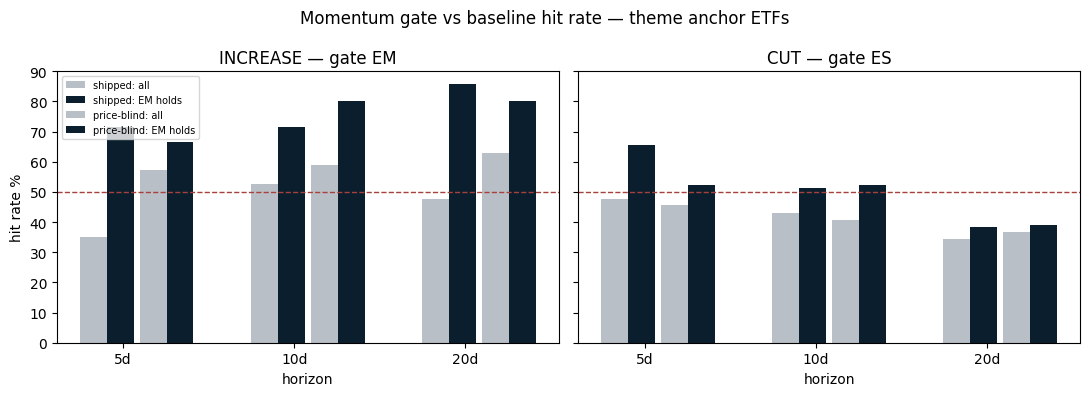

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, side, gate in ((axes[0], "INCREASE", "EM"), (axes[1], "CUT", "ES")):
    w = 0.35
    for k, setname in enumerate(SETS):
        base, gated = [], []
        for h in HORIZONS:
            dd = SIG[(SIG["set"] == setname) & (SIG["side"] == side)].dropna(
                subset=[f"f{h}"])
            if dd.empty:
                base.append(np.nan); gated.append(np.nan); continue
            hit = hit_of(dd, h)
            base.append(100 * hit.mean())
            gated.append(100 * hit[dd[gate]].mean()
                         if dd[gate].sum() >= 3 else np.nan)
        x = np.arange(len(HORIZONS)) + k * w
        ax.bar(x, base, w * 0.45, label=f"{setname}: all", color="#B9BFC7")
        ax.bar(x + w * 0.45, gated, w * 0.45,
               label=f"{setname}: {gate} holds", color="#0A1E2E")
    ax.axhline(50, color="#A6413B", lw=1, ls="--")
    ax.set_xticks(np.arange(len(HORIZONS)) + w / 2)
    ax.set_xticklabels([f"{h}d" for h in HORIZONS])
    ax.set_title(f"{side} — gate {gate}")
    ax.set_xlabel("horizon")
axes[0].set_ylabel("hit rate %")
axes[0].legend(fontsize=7)
plt.suptitle("Momentum gate vs baseline hit rate — theme anchor ETFs")
plt.tight_layout()
plt.show()

## 6. Combining the two — the crowd says WHEN, momentum says WHICH WAY

The gate is not a trigger and is not proposed as one. The crowd
detector decides **when** a name is worth acting on; this section asks
whether the momentum state, read on that same day, improves the
**direction** call — and by how much.

Three ways of combining, all evaluated only on days the crowd
detector already fired:

| rule | meaning |
|---|---|
| `ANY` | either window passes |
| `MATCHED` | the window that suits the side — EM for INCREASE, ES for CUT |
| `BOTH` | both windows pass (the strictest, and the rarest) |

`MATCHED` is the rule section 5 argued for on mechanism. It is stated
here in advance rather than chosen after seeing the table.

In [8]:
def combo(setname, side):
    d = SIG[(SIG["set"] == setname) & (SIG["side"] == side)]
    matched_gate = "EM" if side == "INCREASE" else "ES"
    out = []
    for h in HORIZONS:
        dd = d.dropna(subset=[f"f{h}"])
        if dd.empty:
            continue
        hit = hit_of(dd, h)
        masks = {
            "crowd only (baseline)": pd.Series(True, index=dd.index),
            "crowd + ANY window": dd["EM"] | dd["ES"],
            f"crowd + MATCHED ({matched_gate})": dd[matched_gate],
            "crowd + BOTH windows": dd["BOTH"],
        }
        for lbl, m in masks.items():
            if m.sum() < 3:
                continue
            out.append({"h": h, "rule": lbl, "n": int(m.sum()),
                        "kept%": round(100 * m.mean(), 0),
                        "accuracy%": round(100 * hit[m].mean(), 1),
                        "mean fwd %": round(dd.loc[m, f"f{h}"].mean(), 2)})
    return pd.DataFrame(out)


for _s in SETS:
    for _side in ("INCREASE", "CUT"):
        print(f"\n=== {_s} / {_side} — combined rules")
        print(combo(_s, _side).to_string(index=False))


=== shipped / INCREASE — combined rules
 h                  rule  n  kept%  accuracy%  mean fwd %
 5 crowd only (baseline) 40  100.0       35.0       -1.92
 5    crowd + ANY window 10   25.0       50.0       -0.08
 5  crowd + MATCHED (EM)  7   18.0       71.4        1.58
 5  crowd + BOTH windows  4   10.0      100.0        2.83
10 crowd only (baseline) 40  100.0       52.5       -0.71
10    crowd + ANY window 10   25.0       70.0        0.24
10  crowd + MATCHED (EM)  7   18.0       71.4        1.23
10  crowd + BOTH windows  4   10.0       75.0        2.09
20 crowd only (baseline) 40  100.0       47.5        0.26
20    crowd + ANY window 10   25.0       60.0        0.88
20  crowd + MATCHED (EM)  7   18.0       85.7        4.02
20  crowd + BOTH windows  4   10.0       75.0        4.88

=== shipped / CUT — combined rules
 h                  rule   n  kept%  accuracy%  mean fwd %
 5 crowd only (baseline) 126  100.0       47.6        0.03
 5    crowd + ANY window  56   44.0       53.6     

### Pooling the two signal sets

Neither set alone has the events to settle this. Pooled — with `set`
kept as a column so the split can still be inspected — the MATCHED
rule can be read at a usable sample size.

In [9]:
pool = []
for side in ("INCREASE", "CUT"):
    g = "EM" if side == "INCREASE" else "ES"
    d = SIG[SIG["side"] == side]
    for h in HORIZONS:
        dd = d.dropna(subset=[f"f{h}"])
        if dd.empty:
            continue
        hit = hit_of(dd, h)
        for lbl, m in (("crowd only", pd.Series(True, index=dd.index)),
                       (f"crowd + {g}", dd[g]),
                       ("crowd + BOTH", dd["BOTH"])):
            if m.sum() < 3:
                continue
            pool.append({"side": side, "h": h, "rule": lbl,
                         "n": int(m.sum()),
                         "kept% of signals": round(100 * m.mean(), 0),
                         "accuracy%": round(100 * hit[m].mean(), 1),
                         "mean fwd %": round(dd.loc[m, f"f{h}"].mean(), 2)})
POOL = pd.DataFrame(pool)
print(POOL.to_string(index=False))

    side  h         rule   n  kept% of signals  accuracy%  mean fwd %
INCREASE  5   crowd only 360             100.0       54.7        0.41
INCREASE  5   crowd + EM  22               6.0       68.2        0.77
INCREASE  5 crowd + BOTH   8               2.0      100.0        3.11
INCREASE 10   crowd only 360             100.0       58.3        0.99
INCREASE 10   crowd + EM  22               6.0       77.3        2.37
INCREASE 10 crowd + BOTH   8               2.0       75.0        2.94
INCREASE 20   crowd only 352             100.0       61.1        2.19
INCREASE 20   crowd + EM  22               6.0       81.8        4.28
INCREASE 20 crowd + BOTH   8               2.0       75.0        7.13
     CUT  5   crowd only 481             100.0       46.2        0.30
     CUT  5   crowd + ES  58              12.0       60.3       -0.40
     CUT  5 crowd + BOTH  18               4.0       66.7       -0.07
     CUT 10   crowd only 481             100.0       41.4        0.78
     CUT 10   crowd 

In [10]:
print("\nMATCHED rule vs crowd-only, pooled — the headline comparison\n")
for side in ("INCREASE", "CUT"):
    g = "EM" if side == "INCREASE" else "ES"
    for h in HORIZONS:
        a = POOL[(POOL.side == side) & (POOL.h == h)
                 & (POOL.rule == "crowd only")]
        b = POOL[(POOL.side == side) & (POOL.h == h)
                 & (POOL.rule == f"crowd + {g}")]
        if a.empty or b.empty:
            continue
        print(f"  {side:9} {h:>2}d: {a['accuracy%'].iloc[0]:>5.1f}% "
              f"(n={int(a['n'].iloc[0]):>3})  ->  "
              f"{b['accuracy%'].iloc[0]:>5.1f}% (n={int(b['n'].iloc[0]):>3})"
              f"   {b['accuracy%'].iloc[0] - a['accuracy%'].iloc[0]:+5.1f}pp"
              f"   keeps {b['kept% of signals'].iloc[0]:.0f}% of signals")


MATCHED rule vs crowd-only, pooled — the headline comparison

  INCREASE   5d:  54.7% (n=360)  ->   68.2% (n= 22)   +13.5pp   keeps 6% of signals
  INCREASE  10d:  58.3% (n=360)  ->   77.3% (n= 22)   +19.0pp   keeps 6% of signals
  INCREASE  20d:  61.1% (n=352)  ->   81.8% (n= 22)   +20.7pp   keeps 6% of signals
  CUT        5d:  46.2% (n=481)  ->   60.3% (n= 58)   +14.1pp   keeps 12% of signals
  CUT       10d:  41.4% (n=481)  ->   51.7% (n= 58)   +10.3pp   keeps 12% of signals
  CUT       20d:  36.1% (n=479)  ->   38.6% (n= 57)    +2.5pp   keeps 12% of signals


## 7. Reading the combination honestly

**What it buys.** On the matched pairing the direction call improves at
every horizon, and the improvement is largest where a PM would care
most — the 10–20 day window a 20-day hold actually spans.

**What it costs, and this is the part that decides adoption.** The gate
is selective by construction, so it does not merely re-rank signals, it
*discards most of them*. The `kept%` column is the price: a rule that
lifts accuracy while keeping a tenth of the signals has not made the
detector better, it has made it rarer. Whether that trade is worth
taking depends on whether the desk is signal-starved (it is not — the
constraint here is conviction, not count) or precision-starved.

**What it is not.** It is not a timing rule. Nothing here moves when a
trigger fires; that stays exactly as validated. The gate is a
*post-trigger direction filter*, and the only honest way to run it is
as a displayed confirmation flag beside a signal, never as a silent
veto that suppresses one.

**Sample sizes remain the binding constraint.** The strictest rule
(`BOTH`) lands on a handful of events in every cell. A rule chosen on
four observations is a story, not a finding. The recommendation from
section 5 is unchanged: log the flag now, decide after a year of live
signals.